# Customer Segmentation Using K-Means Clustering

## CMPE 255 — Assignment 1, Part 2

This notebook replicates a customer segmentation experiment using
unsupervised machine learning.

The goal is to group customers with similar characteristics and interpret
the resulting customer segments.

The workflow includes:

1. Dataset Understanding
2. Exploratory Data Analysis
3. Feature Selection
4. Feature Scaling
5. K-Means Clustering
6. Elbow Method
7. Silhouette Score
8. Final Cluster Selection
9. PCA Visualization
10. Customer Segment Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Dataset Understanding

The first step is to load the dataset and inspect its structure before
performing clustering.

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe())

Dataset shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows:
0

Summary statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.50

### Initial Data Understanding

The dataset contains 200 customers and 5 columns.

There are no missing values or duplicate rows, so no major data-cleaning
steps are required before exploratory analysis.

The available customer attributes are:

- `Gender`
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

`CustomerID` is an identifier and will not be used as a clustering feature.

For the initial K-Means experiment, I will focus on three numerical
customer characteristics:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

These variables describe customer demographics, purchasing power, and
spending behavior and can therefore be useful for identifying customer
segments.

`Gender` will not be included in the initial clustering experiment because
K-Means operates on numerical distance. It could be encoded and tested later
if needed.

## 2. Exploratory Data Analysis

Before clustering customers, I will examine the distributions of the
numerical features that may be used by K-Means.

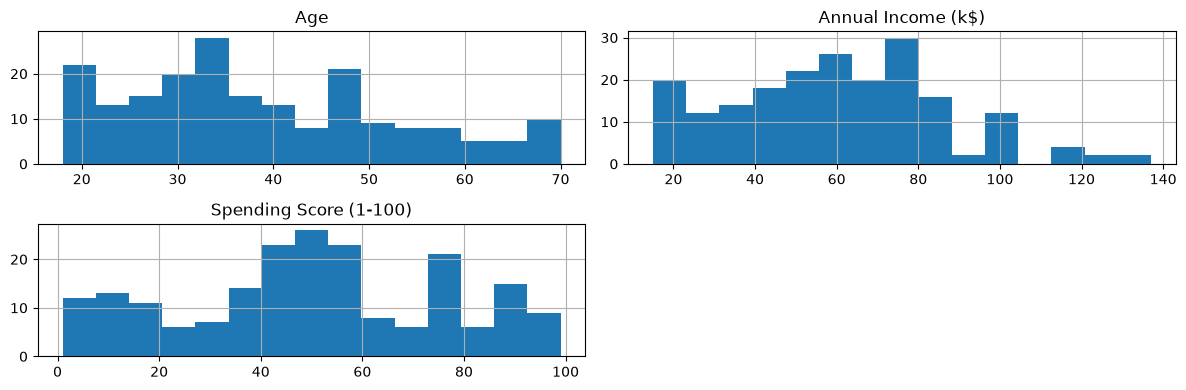

In [4]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

df[features].hist(figsize=(12, 4), bins=15)

plt.tight_layout()
plt.show()

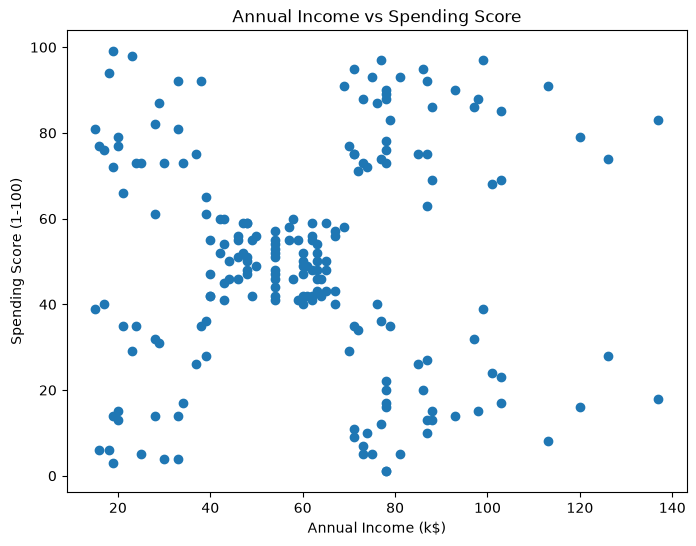

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()

### EDA Interpretation

The numerical features show meaningful variation across the 200 customers.

`Age` is distributed across a wide range, while annual income is concentrated
more heavily in the middle-income range with a smaller number of high-income
customers.

The spending score also varies substantially, with many customers near the
middle of the scale and additional groups with very low or very high spending
scores.

The scatter plot of Annual Income versus Spending Score shows several visible
customer patterns. For example, there appear to be customers with:

- low income and low spending
- low income and high spending
- moderate income and moderate spending
- high income and low spending
- high income and high spending

These visible patterns suggest that clustering may identify meaningful customer
segments. However, the number of clusters will not be selected only by visual
inspection. The Elbow Method and Silhouette Score will be used to evaluate
multiple values of k.

## 3. Feature Selection and Scaling

K-Means clustering is based on distances between observations.

The three numerical features selected for the initial clustering experiment are:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

Because these variables use different numerical scales, they will be standardized
before clustering so that one feature does not dominate the distance calculation.

In [6]:
clustering_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)
print("\nScaled feature means:")
print(X_scaled.mean(axis=0))
print("\nScaled feature standard deviations:")
print(X_scaled.std(axis=0))

Original shape: (200, 3)
Scaled shape: (200, 3)

Scaled feature means:
[-1.02140518e-16 -2.13162821e-16 -1.46549439e-16]

Scaled feature standard deviations:
[1. 1. 1.]


## 4. Selecting the Number of Clusters

The number of clusters, `k`, should not be selected only by visual inspection.

To evaluate multiple values of `k`, I will use:

- the Elbow Method
- the Silhouette Score

The Elbow Method examines how the K-Means inertia decreases as more clusters
are added.

The Silhouette Score measures how well each customer fits within its assigned
cluster compared with other clusters.

Higher silhouette scores generally indicate better-separated clusters.

In [7]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results

,k,Inertia,Silhouette Score
0,2,389.386189,0.335472
1,3,295.212246,0.357793
2,4,205.225147,0.403958
3,5,168.247580,0.416643
4,6,133.868421,0.428417
5,7,117.011555,0.417232
6,8,103.873292,0.408207
7,9,93.092891,0.417693
8,10,82.385154,0.406554


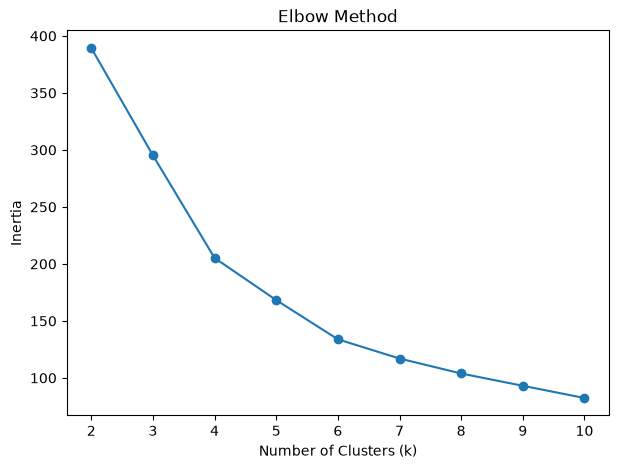

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(results["k"], results["Inertia"], marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig(
    "../figures/elbow_method.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

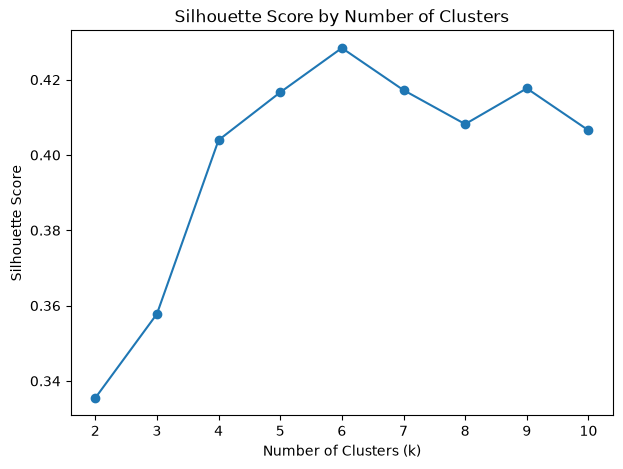

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(
    results["k"],
    results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.savefig(
    "../figures/silhouette_scores.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Cluster Selection Interpretation

The Elbow Method shows a large decrease in inertia as the number of clusters
increases from 2 to approximately 4-6 clusters. After this range, the reduction
in inertia becomes more gradual.

The Silhouette Score provides additional evidence for selecting the number of
clusters.

The highest silhouette score was obtained at:

- `k = 6`
- Silhouette Score = approximately `0.428`

Although the Annual Income vs. Spending Score visualization appeared to show
approximately five customer groups, the clustering model also uses `Age`.

Because the clustering is performed in three dimensions rather than only the
two dimensions shown in the scatter plot, Age may provide additional information
that separates one of the visible groups into smaller customer segments.

Based on both the Elbow Method and the Silhouette Score, I selected **6 clusters**
for the final K-Means model.

## 5. Final K-Means Model

Based on the Elbow Method and Silhouette Score, the final K-Means model will
use six clusters.

In [10]:
final_k = 6

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


In [11]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [12]:
cluster_profile = (
    df.groupby("Cluster")[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile["Customer Count"] = cluster_counts

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,56.33,54.27,49.07,45
1,26.79,57.10,48.13,39
2,41.94,88.94,16.97,33
3,32.69,86.54,82.13,39
4,25.00,25.26,77.61,23
5,45.52,26.29,19.38,21


In [13]:
final_k = 6

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


In [14]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [15]:
cluster_profile = (
    df.groupby("Cluster")[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile["Customer Count"] = cluster_counts

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,56.33,54.27,49.07,45
1,26.79,57.10,48.13,39
2,41.94,88.94,16.97,33
3,32.69,86.54,82.13,39
4,25.00,25.26,77.61,23
5,45.52,26.29,19.38,21


### Customer Segment Interpretation

The six clusters show distinct customer profiles based on age, annual income,
and spending behavior.

- **Cluster 0 — Older Moderate Customers**
  - Average age: 56
  - Average income: $54K
  - Average spending score: 49
  - These customers have moderate income and spending but are relatively older.

- **Cluster 1 — Young Moderate Customers**
  - Average age: 27
  - Average income: $57K
  - Average spending score: 48
  - Their income and spending behavior are similar to Cluster 0, but they are
    substantially younger.

- **Cluster 2 — High-Income Low Spenders**
  - Average age: 42
  - Average income: $89K
  - Average spending score: 17
  - These customers have strong purchasing power but relatively low spending
    activity.

- **Cluster 3 — High-Income High Spenders**
  - Average age: 33
  - Average income: $87K
  - Average spending score: 82
  - This group combines high purchasing power with high spending and may be a
    particularly valuable customer segment.

- **Cluster 4 — Young Low-Income High Spenders**
  - Average age: 25
  - Average income: $25K
  - Average spending score: 78
  - These customers have relatively low income but high spending activity.

- **Cluster 5 — Older Low-Income Low Spenders**
  - Average age: 46
  - Average income: $26K
  - Average spending score: 19
  - This segment has relatively low income and low spending activity.

One important finding is that Clusters 0 and 1 have similar income and spending
levels but differ substantially in age.

This helps explain why the three-dimensional clustering produced six clusters
even though the earlier two-dimensional Annual Income vs. Spending Score plot
appeared to show approximately five groups.

Cluster numbers are arbitrary K-Means labels; the descriptive segment names are
interpretations based on the cluster profiles.

## 6. PCA Visualization

The K-Means model was trained using three standardized features:

- Age
- Annual Income
- Spending Score

Because the clustering exists in three-dimensional feature space, PCA is used
to reduce the data to two dimensions for visualization.

PCA does not determine the clusters. It is used here only to create a
two-dimensional representation of the clustering result.

PCA shape: (200, 2)
Cluster labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]

Explained variance ratio:
[0.44266167 0.33308378]

Total variance explained: 0.7757454566976747


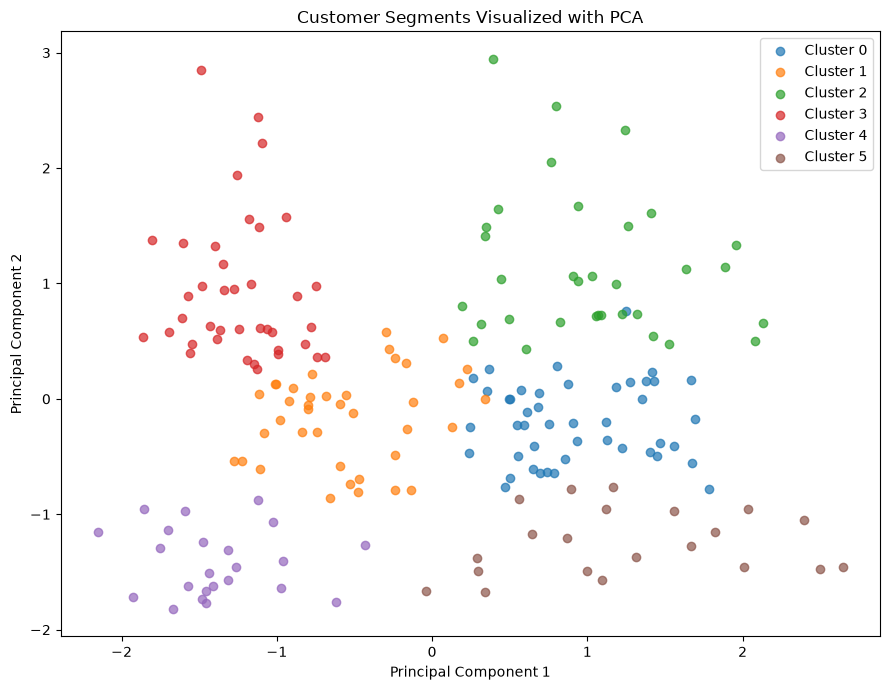

In [16]:
# PCA visualization of the final 6-cluster solution

# Re-create the final K-Means labels to avoid stale notebook variables
final_kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

# Reduce the 3 standardized features to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

print("PCA shape:", X_pca.shape)
print("Cluster labels:", sorted(pca_df["Cluster"].unique()))

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained:",
    pca.explained_variance_ratio_.sum()
)

# Plot
plt.figure(figsize=(9, 7))

for cluster_id in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster_id]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Visualized with PCA")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/customer_segments_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### PCA Interpretation

The first two principal components explain approximately **77.6%** of the
total variance in the three standardized clustering features.

- Principal Component 1 explains approximately 44.3%
- Principal Component 2 explains approximately 33.3%

The PCA visualization shows that the six customer segments occupy generally
different regions of the reduced two-dimensional feature space.

Some overlap remains between several clusters. This is expected because PCA
compresses the original three-dimensional data into two dimensions and does
not preserve all of the original information.

The visualization therefore supports the K-Means clustering result while also
showing that the customer groups are not perfectly separated in every case.

PCA was used only for visualization. The actual K-Means clustering was
performed using all three standardized features.

In [17]:
# Save k-selection results
results.to_csv(
    "../results/k_selection_results.csv",
    index=False
)

# Save cluster profiles
cluster_profile.to_csv(
    "../results/cluster_profiles.csv"
)

# Save customer-level cluster assignments
df.to_csv(
    "../results/customer_segments.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


## 7. Final Conclusion

This experiment used K-Means clustering to identify customer segments based on:

- Age
- Annual Income
- Spending Score

The numerical features were standardized before clustering because K-Means
relies on distance calculations.

Multiple values of `k` were evaluated using both the Elbow Method and
Silhouette Score.

The highest Silhouette Score was approximately **0.428** at `k = 6`, and the
Elbow Method also indicated that a solution in this range was reasonable.

The final six customer segments included:

1. Older Moderate Customers
2. Young Moderate Customers
3. High-Income Low Spenders
4. High-Income High Spenders
5. Young Low-Income High Spenders
6. Older Low-Income Low Spenders

An important finding was that two groups with similar income and spending
behavior were separated mainly by age. This helped explain why the
three-feature K-Means model selected six clusters even though the earlier
two-dimensional income-versus-spending plot appeared to show roughly five
groups.

PCA reduced the three clustering features to two dimensions while preserving
approximately **77.6%** of the total variance. The PCA visualization showed
that the six segments occupy generally distinct regions, although some overlap
remains.

Overall, the experiment demonstrates how unsupervised learning can identify
meaningful customer groups without predefined labels.